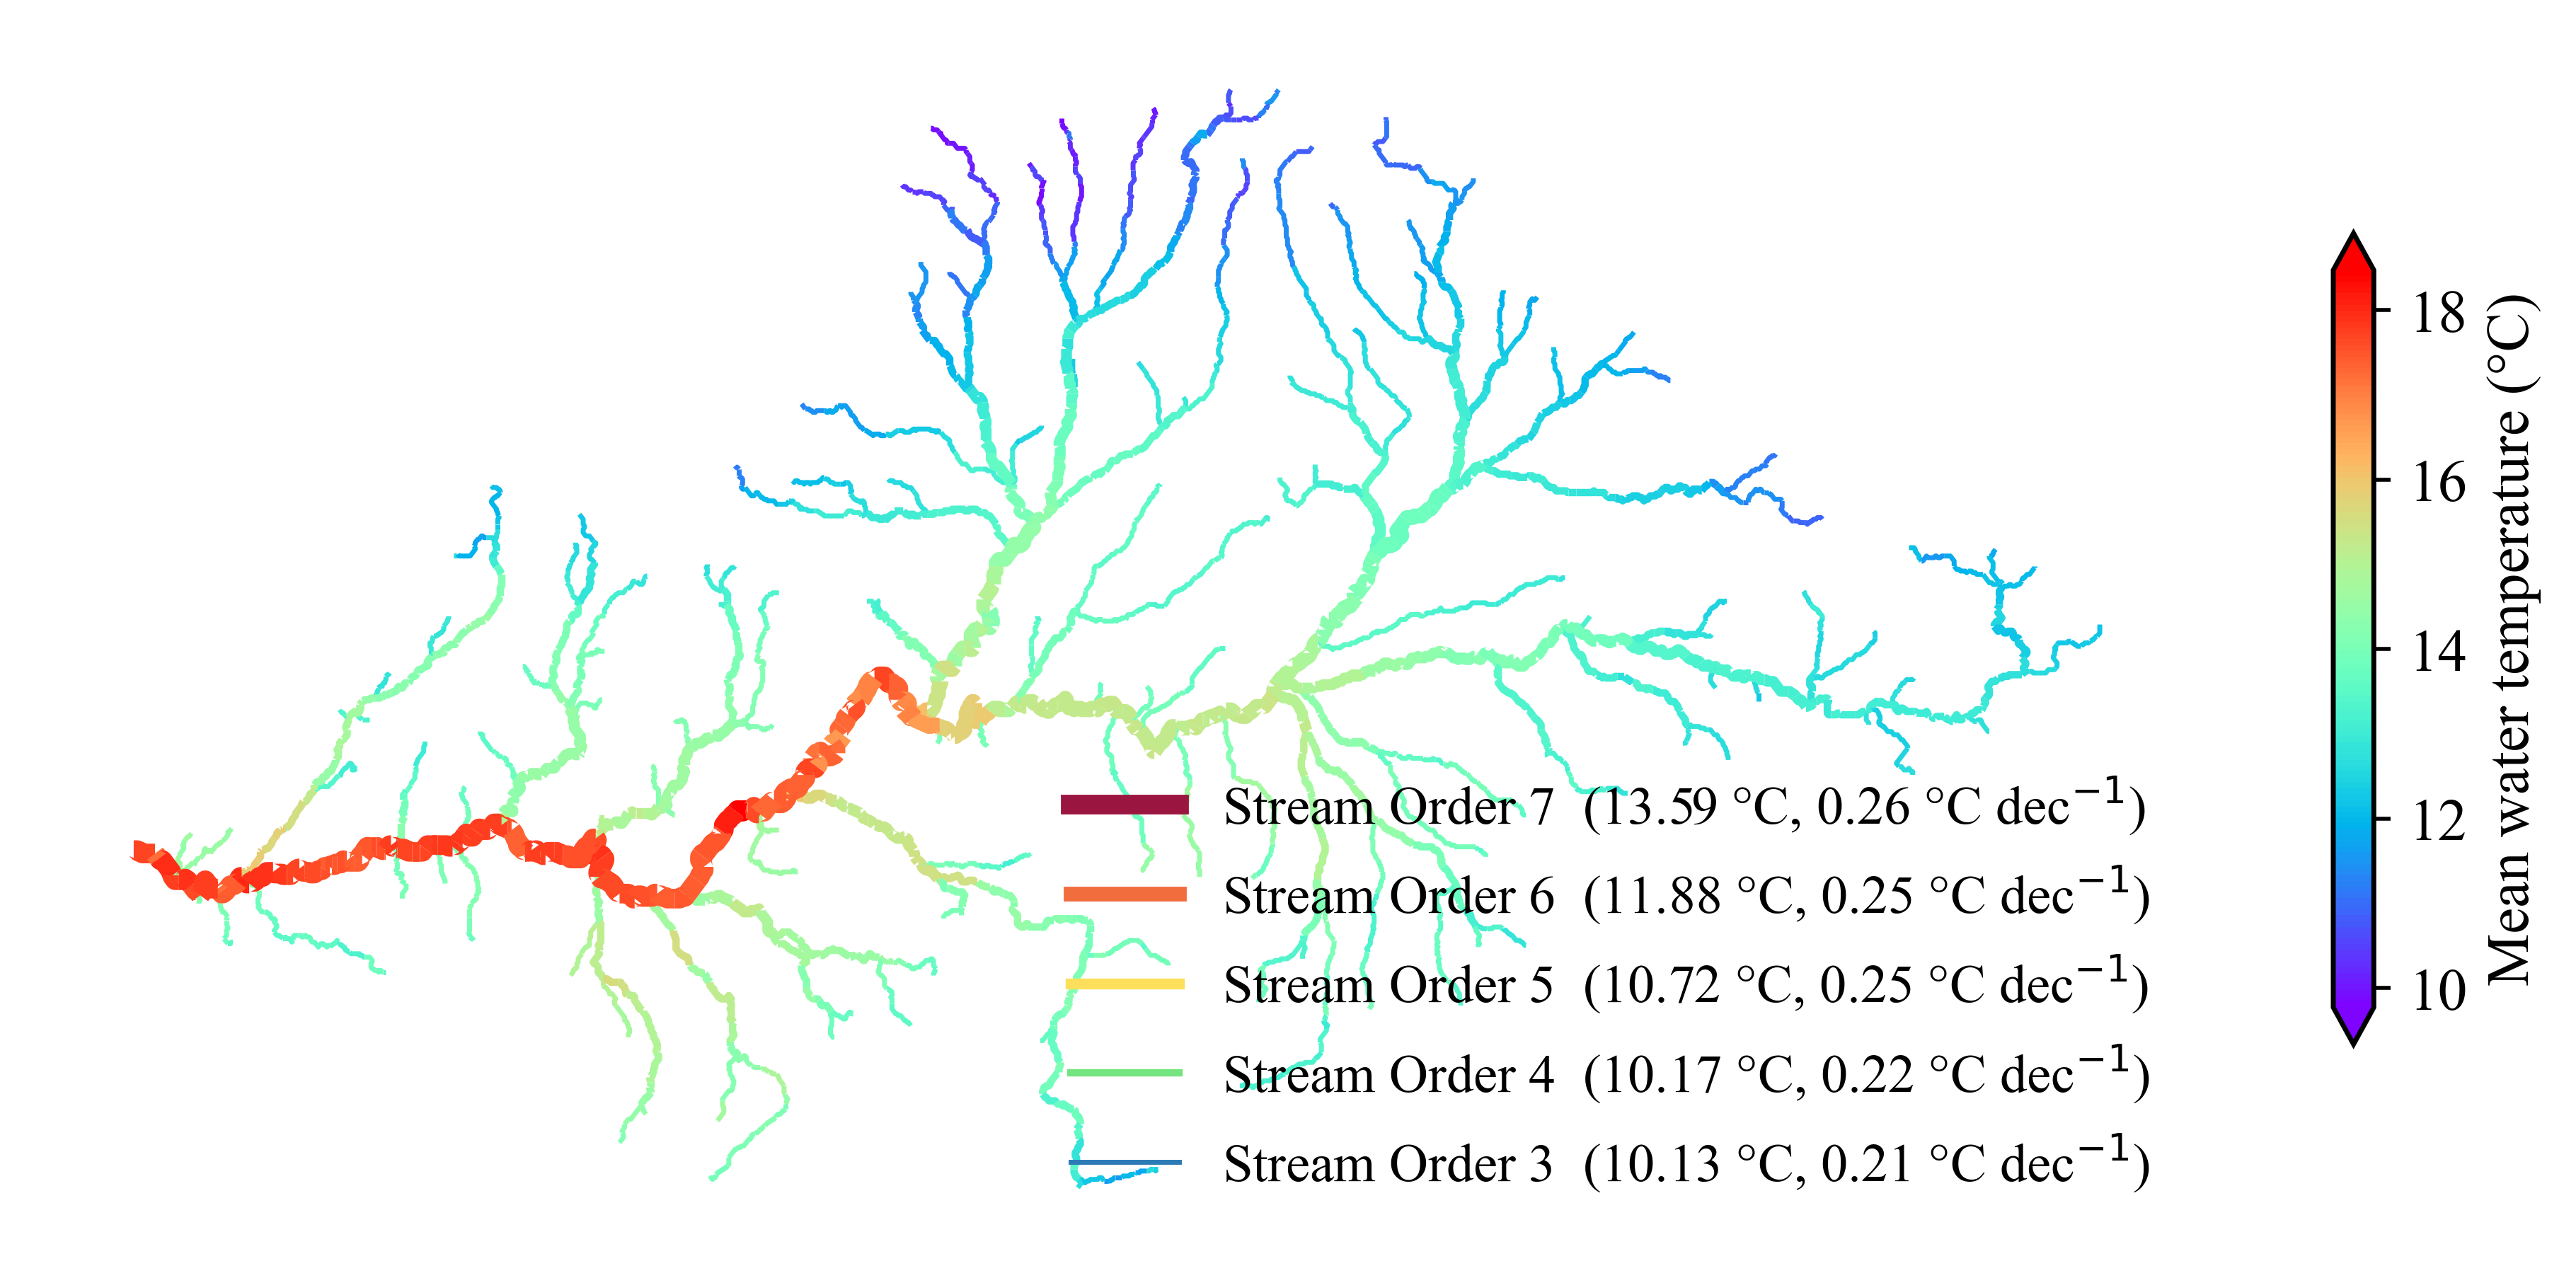

In [ ]:
# -*- coding: utf-8 -*-
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import cmaps
import numpy as np
from matplotlib.lines import Line2D

shp_path = r"D:\NC\Data\rivernet\inputdata\2040019150\rivers.shp"
shp = gpd.read_file(shp_path).to_crs("EPSG:4326")
shp["HYRIV_ID"] = pd.to_numeric(shp["HYRIV_ID"], errors="coerce")
csv = pd.read_parquet(
    r"D:\NC\Data\rivernet\inputdata\seg_annual_temperature_Q.parquet"
)

csv["seg_id_nat"] = pd.to_numeric(csv["seg_id_nat"], errors="coerce")
csv["year"] = pd.to_numeric(csv["year"], errors="coerce")
csv["annual_temp"] = pd.to_numeric(csv["temp_c_pred"], errors="coerce")

csv = csv[(csv["year"] >= 1982) & (csv["year"] <= 2018)].copy()

mean_temp = (
    csv.groupby("seg_id_nat")["annual_temp"]
    .mean()
    .reset_index()
)

mean_temp.rename(columns={"annual_temp": "mean_temp"}, inplace=True)
gdf = shp.merge(
    mean_temp,
    left_on="HYRIV_ID",
    right_on="seg_id_nat",
    how="left"
)

gdf.drop(columns=["seg_id_nat"], inplace=True)
lw_map = {
    3: 1.0,
    4: 1.5,
    5: 2.2,
    6: 3.0,
    7: 4.0
}

order_colors = {
    3: "#2c7bb6",
    4: "#74e481",
    5: "#fddf5c",
    6: "#f26d3e",
    7: "#9a1640"
}

gdf["linewidth"] = gdf["ORD_STRA"].map(lw_map).fillna(0.8)
# mean value for each stream order
temp_ord_mean = pd.DataFrame({
    "ORD_STRA": [3, 4, 5, 6, 7],
    "mean_temp": [10.131926, 10.165179, 10.724246, 11.876098, 13.594619]
})

slope_ord_mean = pd.DataFrame({
    "ORD_STRA": [3, 4, 5, 6, 7],
    "mean_slope_decade": [0.214018, 0.222267, 0.245472, 0.252126, 0.259071]
})
vmin = gdf["mean_temp"].min()
vmax = gdf["mean_temp"].max()
norm = plt.Normalize(vmin=vmin, vmax=vmax)
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.linewidth": 1
})

fig, ax = plt.subplots(figsize=(8, 8), dpi=500)

for order in sorted(gdf["ORD_STRA"].dropna().unique()):
    subset = gdf[gdf["ORD_STRA"] == order]
    subset.plot(
        column="mean_temp",
        cmap=cmaps.MPL_rainbow,
        linewidth=lw_map.get(order, 0.8),
        ax=ax,
        legend=False,
        vmin=vmin,
        vmax=vmax
    )
sm = plt.cm.ScalarMappable(cmap=cmaps.MPL_rainbow, norm=norm)
sm._A = []
cbar = fig.colorbar(sm, ax=ax, shrink=0.3, extend="both")
cbar.set_label("Mean water temperature (°C)")
legend_elements = [
    Line2D(
        [0], [0],
        color=order_colors[o],
        lw=lw_map[o],
        label=(
            f"Stream Order {o}  "
            f"({temp_ord_mean.loc[temp_ord_mean.ORD_STRA == o, 'mean_temp'].values[0]:.2f} °C, "
            f"{slope_ord_mean.loc[slope_ord_mean.ORD_STRA == o, 'mean_slope_decade'].values[0]:.2f} °C dec$^{{-1}}$)"
        )
    )
    for o in [7, 6, 5, 4, 3]
]

ax.legend(
    handles=legend_elements,
    loc="lower right",
    frameon=False,
    fontsize=11
)

ax.axis("off")

plt.tight_layout()
plt.savefig(
    r"C:\Users\Lenovo\Desktop\extendFig14.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()